# Assignment 2: Build Regression Models

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
REPO_ROOT = COURSE.parent
ASSIGNMENT = COURSE / "Week 2" / "Assignment 2"
pd.set_option("display.max_columns", 80)

## Conceptual Question 3

For the model Salary = 50 + 20GPA + 0.07IQ + 35Level + 0.01(GPA x IQ) - 10(GPA x Level), the college-versus-high-school difference at fixed GPA and IQ is 35 - 10GPA.  College graduates earn more when GPA is below 3.5, the two groups are equal at GPA 3.5, and high school graduates earn more when GPA is above 3.5.  Therefore, statement iii is the correct interpretation because the education effect is conditional on GPA rather than constant across all students.  A college graduate with IQ 110 and GPA 4.0 has a predicted salary of 137.1 thousand dollars: 50 + 20(4.0) + 0.07(110) + 35(1) + 0.01(4.0)(110) - 10(4.0)(1).  The small numerical coefficient on GPA x IQ does not by itself prove a weak interaction because statistical evidence depends on the coefficient relative to its standard error and the scale of the variables, not only on the raw coefficient size (James et al., 2023).

## Applied Question 10: Carseats Regression

The Carseats exercise is useful because it forces the model to handle both numeric and qualitative predictors.  Price is numeric, while Urban and US enter as indicator variables.  The applied question asks for the full model, coefficient interpretation, a smaller model, confidence intervals, and diagnostics.  The checks below treat the model as an explanatory regression first and a predictive tool second.

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.39e-23
Time:                        10:54:35   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0435      0.651     20.036   

,0,1
Intercept,11.79032,14.271265
US[T.Yes],0.69152,1.707766
Price,-0.06476,-0.044195


,term,vif
0,Intercept,26.115860
1,US[T.Yes],1.003359
2,Price,1.003359


,assumption_or_check,evidence
0,Linearity / constant variance,Breusch-Pagan p=0.085; residual plot inspected
1,Independence of errors,Durbin-Watson=1.912
2,Residual distribution,Jarque-Bera p=0.688; Q-Q plot inspected
3,Collinearity,Maximum non-intercept VIF=1.003
4,Influential observations,Max leverage=0.043; max Cook's D=0.026
5,Model parsimony,Full R2=0.239; smaller R2=0.239


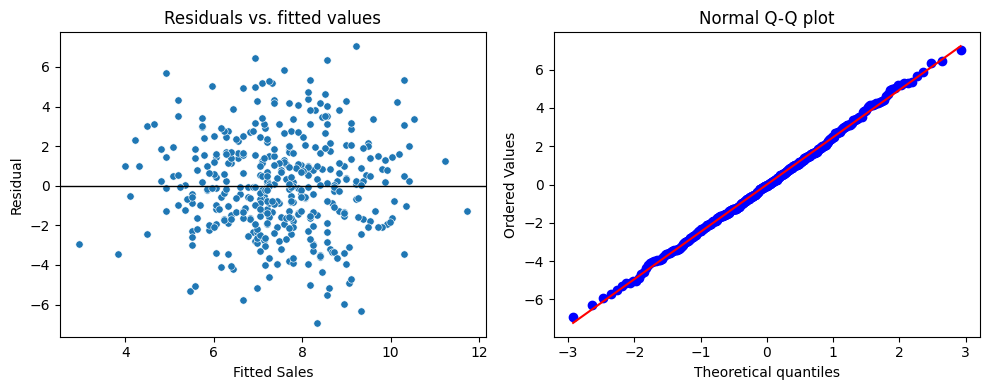

In [2]:
from ISLP import load_data
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

carseats = load_data("Carseats")
model_full = smf.ols("Sales ~ Price + Urban + US", data=carseats).fit()
model_small = smf.ols("Sales ~ Price + US", data=carseats).fit()
print(model_full.summary())
print("\nSmaller model")
print(model_small.summary())
print("\n95% confidence intervals")
display(model_small.conf_int())

vif = pd.DataFrame({
    "term": model_small.model.exog_names,
    "vif": [variance_inflation_factor(model_small.model.exog, i) for i in range(model_small.model.exog.shape[1])],
})
bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(model_small.resid, model_small.model.exog)
influence = model_small.get_influence()
diag = pd.DataFrame({
    "assumption_or_check": [
        "Linearity / constant variance",
        "Independence of errors",
        "Residual distribution",
        "Collinearity",
        "Influential observations",
        "Model parsimony",
    ],
    "evidence": [
        f"Breusch-Pagan p={bp_f_pvalue:.3f}; residual plot inspected",
        f"Durbin-Watson={durbin_watson(model_small.resid):.3f}",
        f"Jarque-Bera p={stats.jarque_bera(model_small.resid).pvalue:.3f}; Q-Q plot inspected",
        f"Maximum non-intercept VIF={vif.loc[vif.term != 'Intercept', 'vif'].max():.3f}",
        f"Max leverage={influence.hat_matrix_diag.max():.3f}; max Cook's D={influence.cooks_distance[0].max():.3f}",
        f"Full R2={model_full.rsquared:.3f}; smaller R2={model_small.rsquared:.3f}",
    ],
})
display(vif)
display(diag)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(x=model_small.fittedvalues, y=model_small.resid, ax=axes[0], s=28)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals vs. fitted values")
axes[0].set_xlabel("Fitted Sales")
axes[0].set_ylabel("Residual")
stats.probplot(model_small.resid, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot")
plt.tight_layout()
plt.show()

The full model shows that Price and US are statistically meaningful, while Urban is not.  The smaller model keeps Price and US because those predictors have evidence of association with Sales, and removing Urban leaves R2 essentially unchanged.  The fitted smaller equation is Sales = 13.031 - 0.0545(Price) + 1.200(US).  The negative Price coefficient means expected sales decrease by about 0.0545 thousand units for each one-dollar increase in price, holding the US indicator constant.  The positive US coefficient means stores in the United States are expected to sell about 1.2 thousand more units than non-US stores at the same price.  The confidence intervals exclude zero for Price and US, which supports rejecting the null hypotheses for those predictors.  The diagnostics support a cautious interpretation: Durbin-Watson is close to 2, VIF values are low, the Jarque-Bera result does not show strong residual non-normality, and the visual residual checks do not show a pattern severe enough to invalidate the model.  The low R2 still matters because the model explains only part of sales variation, so it is better for directional interpretation than for complete forecasting.

## Kaggle Regression with Abalone

Two Kaggle submissions were made for the Abalone regression competition: a ridge regression baseline and a random forest regression model.  The notebook keeps local validation separate from Kaggle scoring so the interpretation is not based only on the public leaderboard.  Ridge is used as a regularized linear benchmark, while random forest is used as a nonlinear ensemble benchmark that can capture interactions among abalone measurements (Hastie et al., 2009).

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

abalone = pd.read_csv(KAGGLE / "playground-series-s4e4" / "train.csv")
X = abalone.drop(columns=["Rings"])
y = abalone["Rings"]
cat = ["Sex"]
num = [c for c in X.columns if c not in cat + ["id"]]
pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ("num", StandardScaler(), num),
], remainder="drop")
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=.2, random_state=RANDOM_STATE)
models = {
    "Ridge": Pipeline([("pre", pre), ("model", Ridge(alpha=10.0))]),
    "Random forest": Pipeline([("pre", pre), ("model", RandomForestRegressor(n_estimators=120, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1))]),
}
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.maximum(model.predict(X_valid), 1)
    rows.append({"model": name, "validation_rmsle": np.sqrt(mean_squared_log_error(y_valid, pred))})
model_results = pd.DataFrame(rows).sort_values("validation_rmsle")
display(model_results)

,model,validation_rmsle
1,Random forest,0.153956
0,Ridge,0.165662


In [4]:
import re
import subprocess

status_path = SUBMISSIONS / "kaggle_submission_status_playground-series-s4e4.txt"
text = status_path.read_text(encoding="utf-16", errors="ignore")
a2_lines = [line for line in text.splitlines() if "A2_" in line]
records = []
for line in a2_lines:
    parts = re.split(r"\s{2,}", line.strip())
    records.append({
        "ref": parts[0],
        "fileName": parts[1],
        "date": parts[2],
        "description": parts[3],
        "status": parts[4],
        "publicScore": parts[5],
        "privateScore": parts[6],
    })
display(pd.DataFrame(records))

submission_evidence = pd.DataFrame({
    "submission_file": [
        "A2_ridge_playground_series_s4e4.csv",
        "A2_random_forest_playground_series_s4e4.csv",
    ],
})
submission_evidence["exists_locally"] = submission_evidence["submission_file"].map(lambda name: (SUBMISSIONS / name).exists())
display(submission_evidence)

github_remote = subprocess.check_output(["git", "config", "--get", "remote.origin.url"], cwd=REPO_ROOT, text=True).strip()
display(pd.DataFrame([
    {"evidence": "GitHub repository remote", "value": github_remote},
    {"evidence": "Notebook path in repository", "value": "DDS-8555 - Predictive Analysis/Week 2/Assignment 2/MaldonadoJDDS8555-2.ipynb"},
]))

,ref,fileName,date,description,status,publicScore,privateScore
0,52966788,A2_random_forest_playground_series_s4e4.csv,2026-05-23 21:27:11.893000,DDS-8555 A2 random forest regression,SubmissionStatus.COMPLETE,0.14927,0.14943
1,52966787,A2_ridge_playground_series_s4e4.csv,2026-05-23 21:27:09.197000,DDS-8555 A2 ridge regression baseline,SubmissionStatus.COMPLETE,0.16442,0.16372


,submission_file,exists_locally
0,A2_ridge_playground_series_s4e4.csv,True
1,A2_random_forest_playground_series_s4e4.csv,True


,evidence,value
0,GitHub repository remote,https://github.com/maldo81/data-science-phd.git
1,Notebook path in repository,DDS-8555 - Predictive Analysis/Week 2/Assignme...


## Interpretation

The ridge model provides a stable linear benchmark, while the random forest can capture interactions and nonlinear structure without manually specifying every term.  The validation results and Kaggle scores both favored the random forest submission, which strengthens the case that the abalone measurements contain nonlinear signal.  Regression assumptions are most directly relevant to the linear models: the Carseats analysis checks linearity and constant variance through residual structure, independence through Durbin-Watson, collinearity through VIF, and residual shape through Jarque-Bera and Q-Q diagnostics.  The random forest relaxes the linearity and normal-residual assumptions, but it still requires held-out validation because flexibility can hide overfitting.  The practical finding is therefore split: the simpler regression is useful for explaining directional effects, while the random forest is the better submission model for this prediction task.

## References

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.).  Springer. https://doi.org/10.1007/978-0-387-84858-7

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*.  Springer. https://doi.org/10.1007/978-3-031-38747-0

Snee, R.  D. (1977).  Validation of regression models: Methods and examples. *Technometrics, 19*(4), 415-428. https://doi.org/10.1080/00401706.1977.10489581